# Candidate Tokenizer Analysis

This notebook analyzes tokenizers from various LLM models to evaluate their vocabulary composition, token length distributions, and language coverage.

## Candidate Tokenizers

| Model | HuggingFace Link |
|-------|------------------|
| DeepSeek V3.2 | https://huggingface.co/deepseek-ai/DeepSeek-V3.2 |
| DeepSeek Coder 33B | https://huggingface.co/deepseek-ai/deepseek-coder-33b-instruct |
| Qwen3 235B | https://huggingface.co/Qwen/Qwen3-235B-A22B-Thinking-2507-FP8 |
| Qwen3 Coder 480B | https://huggingface.co/Qwen/Qwen3-Coder-480B-A35B-Instruct |
| Gemma 2 27B | https://huggingface.co/google/gemma-2-27b |
| GPT-OSS 120B | https://huggingface.co/openai/gpt-oss-120b |
| OLMo 3 32B | https://huggingface.co/allenai/Olmo-3-1125-32B |
| SERA 32B | https://huggingface.co/allenai/SERA-32B-GA |
| Mistral Large 3 675B | https://huggingface.co/mistralai/Mistral-Large-3-675B-Base-2512 |
| ByteDance Seed 36B | https://huggingface.co/ByteDance-Seed/Seed-OSS-36B-Base |
| Llama 3.3 | https://huggingface.co/collections/meta-llama/llama-33 |

In [1]:
# Cell 1: Import libraries and setup
import json
import os
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up paths using relative paths
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
CHARTS_DIR = Path("charts")

# Ensure output directories exist
OUTPUT_DIR.mkdir(exist_ok=True)
CHARTS_DIR.mkdir(exist_ok=True)

# Get all tokenizer files
tokenizer_files = list(DATA_DIR.glob("*_tokenizer.json"))
print(f"Found {len(tokenizer_files)} tokenizer files:")
for f in tokenizer_files:
    print(f"  - {f.name}")

Found 10 tokenizer files:
  - byted_tokenizer.json
  - dscode_tokenizer.json
  - ds_tokenizer.json
  - gemma_tokenizer.json
  - gptoss_tokenizer.json
  - mistral_tokenizer.json
  - olmocode_tokenizer.json
  - olmo_tokenizer.json
  - qwencode_tokenizer.json
  - qwen_tokenizer.json


In [ ]:
# Cell 2: Helper functions for tokenizer loading and analysis

def load_tokenizer(file_path):
    """Load a tokenizer JSON file and extract vocabulary"""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    vocab = {}
    added_tokens = []
    tokenizer_type = "Unknown"
    
    # Extract vocabulary from model section
    if 'model' in data and 'vocab' in data['model']:
        vocab = data['model']['vocab']
        tokenizer_type = data['model'].get('type', 'Unknown')
    
    # Extract added tokens (special tokens)
    if 'added_tokens' in data:
        added_tokens = data['added_tokens']
    
    return {
        'vocab': vocab,
        'added_tokens': added_tokens,
        'type': tokenizer_type,
        'name': file_path.stem.replace('_tokenizer', '')
    }

# Byte-level BPE decoder (critical for proper token decoding)
def create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

BYTE_DECODER = create_byte_decoder()

def decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [BYTE_DECODER.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def get_token_length(token):
    """Get the actual character length of a token after decoding"""
    decoded = decode_bpe_token(token)
    return len(decoded)

def detect_language(token):
    """Detect the language/script of a token using Unicode ranges on decoded text"""
    decoded = decode_bpe_token(token)
    
    # Skip tokens that failed to decode properly
    if '�' in decoded:
        return 'Byte Fragments'
    
    # Remove leading/trailing whitespace for analysis
    text = decoded.strip()
    if not text:
        return 'Whitespace/Control'
    
    # Count characters by script using Unicode code points
    from collections import Counter
    scripts = Counter()
    
    for char in text:
        code = ord(char)
        
        # CJK
        if 0x4E00 <= code <= 0x9FFF or 0x3400 <= code <= 0x4DBF:
            scripts["Chinese"] += 1
        elif 0x3040 <= code <= 0x309F:
            scripts["Japanese (Hiragana)"] += 1
        elif 0x30A0 <= code <= 0x30FF:
            scripts["Japanese (Katakana)"] += 1
        elif 0xAC00 <= code <= 0xD7AF:
            scripts["Korean"] += 1
        elif 0x0400 <= code <= 0x04FF:
            scripts["Cyrillic"] += 1
        elif 0x0600 <= code <= 0x06FF or 0x0750 <= code <= 0x077F:
            scripts["Arabic"] += 1
        elif 0x0590 <= code <= 0x05FF:
            scripts["Hebrew"] += 1
        elif 0x0370 <= code <= 0x03FF:
            scripts["Greek"] += 1
        elif 0x0E00 <= code <= 0x0E7F:
            scripts["Thai"] += 1
        # Indic scripts
        elif 0x0900 <= code <= 0x097F:
            scripts["Hindi (Devanagari)"] += 1
        elif 0x0980 <= code <= 0x09FF:
            scripts["Bengali"] += 1
        elif 0x0A00 <= code <= 0x0A7F:
            scripts["Punjabi (Gurmukhi)"] += 1
        elif 0x0A80 <= code <= 0x0AFF:
            scripts["Gujarati"] += 1
        elif 0x0B00 <= code <= 0x0B7F:
            scripts["Odia"] += 1
        elif 0x0B80 <= code <= 0x0BFF:
            scripts["Tamil"] += 1
        elif 0x0C00 <= code <= 0x0C7F:
            scripts["Telugu"] += 1
        elif 0x0C80 <= code <= 0x0CFF:
            scripts["Kannada"] += 1
        elif 0x0D00 <= code <= 0x0D7F:
            scripts["Malayalam"] += 1
        elif 0x0D80 <= code <= 0x0DFF:
            scripts["Sinhala"] += 1
        # Latin and basic characters
        elif code <= 0x007F:
            if char.isalpha():
                scripts["English/ASCII"] += 1
            elif char.isdigit():
                scripts["Numbers"] += 1
            elif char.isspace():
                scripts["Whitespace"] += 1
            else:
                scripts["Punctuation/Symbols"] += 1
        elif 0x0080 <= code <= 0x024F:
            scripts["Latin Extended"] += 1
        else:
            scripts["Other"] += 1
    
    if scripts:
        return max(scripts.items(), key=lambda x: x[1])[0]
    return 'Other'

def is_indic_token(token):
    """Check if token contains Indic script characters"""
    lang = detect_language(token)
    indic_langs = ['Hindi (Devanagari)', 'Bengali', 'Tamil', 'Telugu', 'Kannada', 
                   'Malayalam', 'Gujarati', 'Odia', 'Punjabi (Gurmukhi)', 'Sinhala']
    return lang in indic_langs

def is_english_token(token):
    """Check if token is primarily English/ASCII"""
    return detect_language(token) == 'English/ASCII'

def is_code_token(token):
    """Check if token is related to programming/code"""
    decoded = decode_bpe_token(token)
    
    # Code-related patterns
    code_patterns = [
        r'^(def|class|function|const|let|var|import|from|return|if|else|elif|for|while|try|except|catch|finally|async|await|yield|lambda|public|private|protected|static|void|int|float|double|string|bool|null|None|true|false|True|False|undefined|this|self|super|new|delete|throw|throws|extends|implements|interface|abstract|virtual|override|final|package|namespace|using|include|require|export|module)$',
        r'^(console|print|printf|println|log|debug|error|warn|info)$',
        r'^(Array|List|Dict|Map|Set|Object|String|Number|Boolean|Function|Promise|Observable)$',
        r'^\s*(//|#|/\*|\*/|<!--|-->)',  # Comments
        r'^[{}\[\]();,.]$',  # Brackets and punctuation
        r'^(=>|->|::|&&|\|\||==|!=|<=|>=|\+=|-=|\*=|/=)$',  # Operators
        r'^__(init|main|name|str|repr|len|iter|next|call|getattr|setattr)__$',  # Python dunder
        r'^\s+$',  # Indentation (important for code)
        r'^(GET|POST|PUT|DELETE|PATCH|HTTP|API|REST|GraphQL)$',  # API related
        r'^(SELECT|INSERT|UPDATE|DELETE|FROM|WHERE|JOIN|ORDER|GROUP|BY|AND|OR|NOT|CREATE|DROP|TABLE|INDEX|PRIMARY|KEY|FOREIGN|REFERENCES)$',  # SQL
    ]
    
    for pattern in code_patterns:
        if re.search(pattern, decoded, re.IGNORECASE):
            return True
    
    # Check for camelCase or snake_case patterns
    if re.match(r'^[a-z]+[A-Z][a-zA-Z]*$', decoded.strip()):  # camelCase
        return True
    if re.match(r'^[a-z]+(_[a-z]+)+$', decoded.strip()):  # snake_case
        return True
    
    return False

def is_json_token(token):
    """Check if token is related to JSON handling"""
    decoded = decode_bpe_token(token)
    
    json_patterns = [
        r'^[{}\[\]:,]$',  # JSON structural characters
        r'^"[^"]*"$',  # Quoted strings
        r'^(true|false|null)$',  # JSON literals
        r'^-?\d+\.?\d*$',  # Numbers
        r'^\s*(json|JSON|Json)$',
        r'^\s*(stringify|parse|dumps|loads|serialize|deserialize)$',
    ]
    
    for pattern in json_patterns:
        if re.search(pattern, decoded, re.IGNORECASE):
            return True
    
    return False

def is_function_call_token(token):
    """Check if token is related to function call handling"""
    decoded = decode_bpe_token(token)
    
    function_patterns = [
        r'^(function|func|fn|def|method|procedure|subroutine)$',
        r'^(call|invoke|execute|run|apply|bind)$',
        r'^(args|arguments|params|parameters|kwargs|options)$',
        r'^(callback|handler|listener|observer)$',
        r'^(async|await|promise|then|catch|finally)$',
        r'^(<\|.*\|>)$',  # Special function call tokens
        r'^(tool|tools|function_call|tool_call|tool_use)$',
        r'^\(|\)$',  # Parentheses
    ]
    
    for pattern in function_patterns:
        if re.search(pattern, decoded, re.IGNORECASE):
            return True
    
    return False

print("Helper functions loaded successfully!")
print("Using byte-level BPE decoder for proper token decoding.")

Helper functions loaded successfully!


Loading tokenizers...
  Loading byted_tokenizer.json...
  Loading dscode_tokenizer.json...
  Loading ds_tokenizer.json...
  Loading gemma_tokenizer.json...
  Loading gptoss_tokenizer.json...
  Loading mistral_tokenizer.json...
  Loading olmocode_tokenizer.json...
  Loading olmo_tokenizer.json...
  Loading qwencode_tokenizer.json...
  Loading qwen_tokenizer.json...

1. VOCABULARY SIZE STATISTICS
Tokenizer Type  Vocab Size  Base Vocab  Added Tokens
    gemma  BPE      256247      255998           249
   gptoss  BPE      200019      199998            21
    byted  BPE      155249      155121           128
     qwen  BPE      151669      151643            26
 qwencode  BPE      151669      151643            26
 olmocode  BPE      151669      151643            26
  mistral  BPE      132072      131072          1000
       ds  BPE      128818      128000           818
     olmo  BPE      100300      100278            22
   dscode  BPE       32022       32000            22


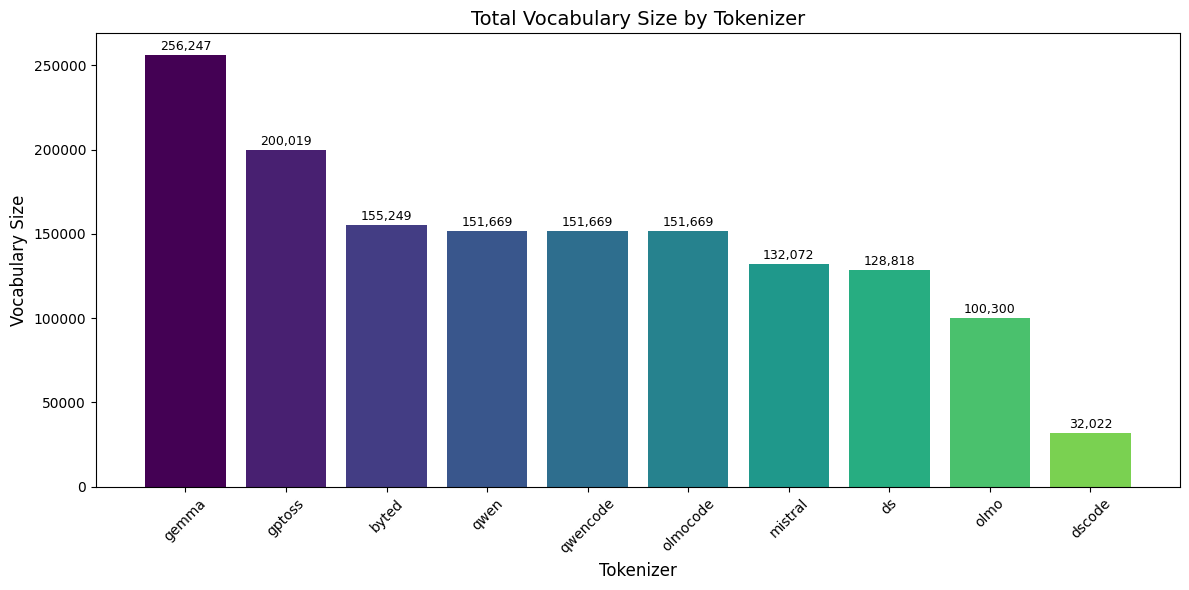


Chart saved to charts\vocab_sizes.png


In [3]:
# Cell 3: Load all tokenizers and compute basic statistics

tokenizers = {}
basic_stats = []

print("Loading tokenizers...")
for file_path in tokenizer_files:
    print(f"  Loading {file_path.name}...")
    tok_data = load_tokenizer(file_path)
    tokenizers[tok_data['name']] = tok_data
    
    vocab_size = len(tok_data['vocab']) + len(tok_data['added_tokens'])
    basic_stats.append({
        'Tokenizer': tok_data['name'],
        'Type': tok_data['type'],
        'Vocab Size': vocab_size,
        'Base Vocab': len(tok_data['vocab']),
        'Added Tokens': len(tok_data['added_tokens'])
    })

# Create DataFrame for basic stats
df_basic = pd.DataFrame(basic_stats).sort_values('Vocab Size', ascending=False)
print("\n" + "="*60)
print("1. VOCABULARY SIZE STATISTICS")
print("="*60)
print(df_basic.to_string(index=False))

# Create bar chart for vocabulary sizes
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df_basic)))
bars = ax.bar(df_basic['Tokenizer'], df_basic['Vocab Size'], color=colors)
ax.set_xlabel('Tokenizer', fontsize=12)
ax.set_ylabel('Vocabulary Size', fontsize=12)
ax.set_title('Total Vocabulary Size by Tokenizer', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, df_basic['Vocab Size']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'vocab_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nChart saved to {CHARTS_DIR / 'vocab_sizes.png'}")

2. LARGEST TOKENS ANALYSIS

BYTED - Top 10 Largest Tokens:
--------------------------------------------------
   1. Length: 512 chars - '                                                  '
   2. Length: 256 chars - '                                                  '
   3. Length: 192 chars - '                                                  '
   4. Length: 128 chars - '                                                  '
   5. Length: 112 chars - '                                                  '
   6. Length:  96 chars - '..................................................'
   7. Length:  80 chars - '**************************************************'
   8. Length:  80 chars - '--------------------------------------------------'
   9. Length:  77 chars - '/*************************************************'
  10. Length:  77 chars - ' *************************************************'

DSCODE - Top 10 Largest Tokens:
--------------------------------------------------
   1. Length:  6

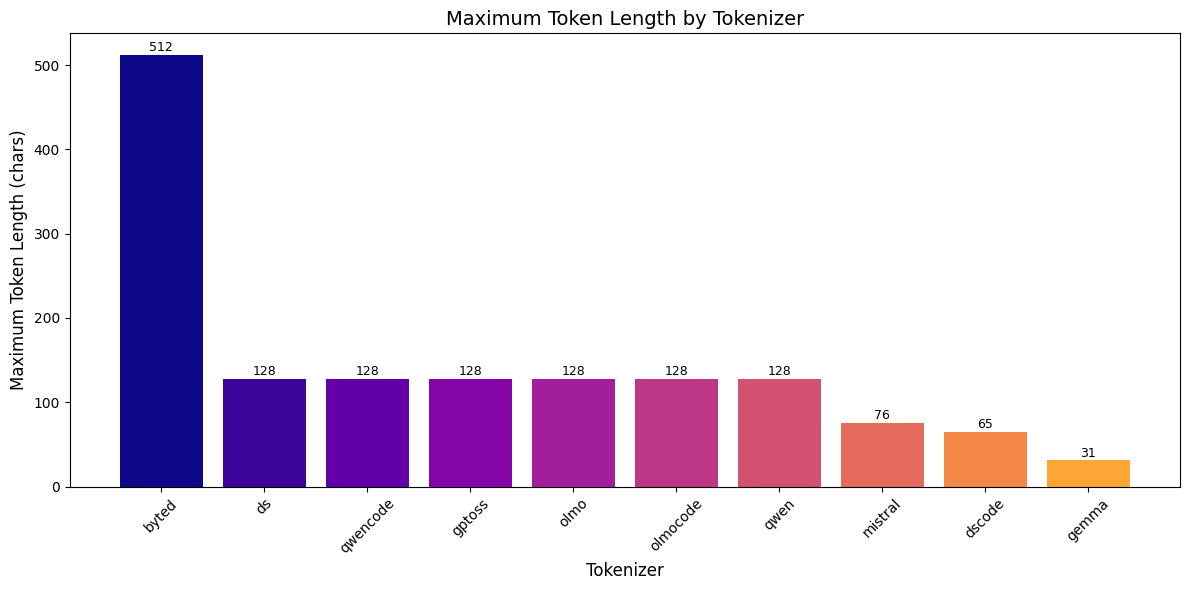

In [4]:
# Cell 4: Analyze largest tokens and tokens over 32 characters

print("="*60)
print("2. LARGEST TOKENS ANALYSIS")
print("="*60)

largest_tokens_data = []

for name, tok_data in tokenizers.items():
    # Get tokens with their lengths
    token_lengths = [(token, get_token_length(token)) for token in tok_data['vocab'].keys()]
    token_lengths.sort(key=lambda x: x[1], reverse=True)
    
    # Top 10 largest tokens
    top_10 = token_lengths[:10]
    
    print(f"\n{name.upper()} - Top 10 Largest Tokens:")
    print("-" * 50)
    for i, (token, length) in enumerate(top_10, 1):
        decoded = decode_bpe_token(token)[:50]  # Truncate for display
        print(f"  {i:2}. Length: {length:3} chars - {repr(decoded)[:60]}")
    
    # Store max token length
    max_length = token_lengths[0][1] if token_lengths else 0
    largest_tokens_data.append({
        'Tokenizer': name,
        'Max Token Length': max_length,
        'Sample Largest Token': repr(decode_bpe_token(top_10[0][0])[:30]) if top_10 else 'N/A'
    })

# Create comparison chart
df_largest = pd.DataFrame(largest_tokens_data).sort_values('Max Token Length', ascending=False)
print("\n\nSummary - Maximum Token Lengths:")
print(df_largest.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0, 0.8, len(df_largest)))
bars = ax.bar(df_largest['Tokenizer'], df_largest['Max Token Length'], color=colors)
ax.set_xlabel('Tokenizer', fontsize=12)
ax.set_ylabel('Maximum Token Length (chars)', fontsize=12)
ax.set_title('Maximum Token Length by Tokenizer', fontsize=14)
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, df_largest['Max Token Length']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'max_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

3. TOKENS JUST OVER 32 CHARACTERS

BYTED:
  Total tokens > 32 chars: 75 (0.05%)
  Tokens 33-40 chars: 19
  Sample tokens (33-40 chars):
    - Length 33: '                                 '
    - Length 33: ' --------------------------------'
    - Length 33: ' Ð³Ð¾ÑģÑĥÐ´Ð°ÑĢÑģÑĤÐ²ÐµÐ½Ð½Ð¾Ð³Ð¾'
    - Length 33: ' ________________________________'
    - Length 33: '                                \n'

DSCODE:
  Total tokens > 32 chars: 22 (0.07%)
  Tokens 33-40 chars: 10
  Sample tokens (33-40 chars):
    - Length 33: '                                <'
    - Length 33: '                                 '
    - Length 34: '                                  '
    - Length 35: '                                   '
    - Length 36: '                                    '

DS:
  Total tokens > 32 chars: 71 (0.06%)
  Tokens 33-40 chars: 21
  Sample tokens (33-40 chars):
    - Length 33: '                                 '
    - Length 33: 'æĸ°æĹ¶ä»£ä¸ŃåĽ½çī¹èī²ç¤¾ä¼ļä¸»ä¹ī'
    - Length 33: ' 

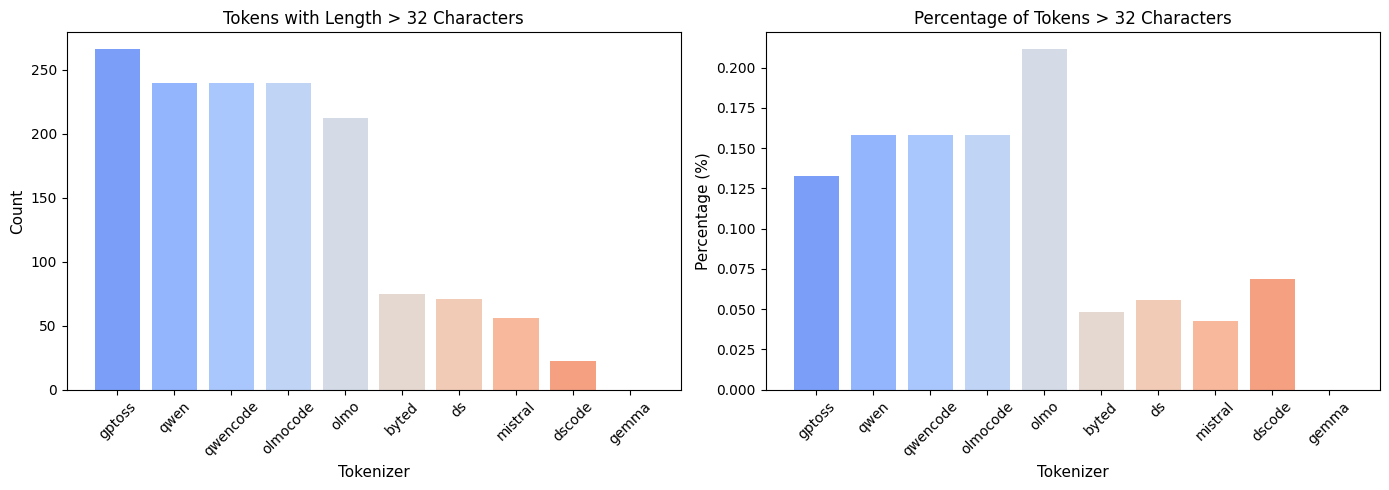

In [5]:
# Cell 5: Tokens just over 32 characters analysis

print("="*60)
print("3. TOKENS JUST OVER 32 CHARACTERS")
print("="*60)

tokens_over_32_data = []

for name, tok_data in tokenizers.items():
    # Get tokens with length > 32
    tokens_over_32 = [(token, get_token_length(token)) 
                       for token in tok_data['vocab'].keys() 
                       if get_token_length(token) > 32]
    
    # Sort by length
    tokens_over_32.sort(key=lambda x: x[1])
    
    # Get tokens just over 32 (32 < length <= 40)
    tokens_just_over = [(t, l) for t, l in tokens_over_32 if 32 < l <= 40]
    
    total_vocab = len(tok_data['vocab'])
    count_over_32 = len(tokens_over_32)
    pct_over_32 = (count_over_32 / total_vocab * 100) if total_vocab > 0 else 0
    
    print(f"\n{name.upper()}:")
    print(f"  Total tokens > 32 chars: {count_over_32:,} ({pct_over_32:.2f}%)")
    print(f"  Tokens 33-40 chars: {len(tokens_just_over):,}")
    
    if tokens_just_over:
        print("  Sample tokens (33-40 chars):")
        for token, length in tokens_just_over[:5]:
            decoded = decode_bpe_token(token)[:45]
            print(f"    - Length {length}: {repr(decoded)[:50]}")
    
    tokens_over_32_data.append({
        'Tokenizer': name,
        'Tokens > 32': count_over_32,
        '% > 32': pct_over_32,
        'Tokens 33-40': len(tokens_just_over)
    })

# Create summary DataFrame
df_over_32 = pd.DataFrame(tokens_over_32_data).sort_values('Tokens > 32', ascending=False)
print("\n\nSummary - Tokens Over 32 Characters:")
print(df_over_32.to_string(index=False))

# Create chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count chart
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(df_over_32)))
ax1.bar(df_over_32['Tokenizer'], df_over_32['Tokens > 32'], color=colors)
ax1.set_xlabel('Tokenizer', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Tokens with Length > 32 Characters', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Percentage chart
ax2.bar(df_over_32['Tokenizer'], df_over_32['% > 32'], color=colors)
ax2.set_xlabel('Tokenizer', fontsize=11)
ax2.set_ylabel('Percentage (%)', fontsize=11)
ax2.set_title('Percentage of Tokens > 32 Characters', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'tokens_over_32.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cell 6: Language distribution analysis

print("="*60)
print("4. TOKEN LANGUAGE/SCRIPT DISTRIBUTION")
print("="*60)

language_stats = {}

for name, tok_data in tokenizers.items():
    print(f"\nAnalyzing {name}...")
    lang_counts = defaultdict(int)
    
    for token in tok_data['vocab'].keys():
        lang = detect_language(token)
        lang_counts[lang] += 1
    
    language_stats[name] = dict(lang_counts)
    
    # Print top languages
    sorted_langs = sorted(lang_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"  Top languages/scripts in {name}:")
    for lang, count in sorted_langs[:10]:
        pct = count / len(tok_data['vocab']) * 100
        print(f"    {lang}: {count:,} ({pct:.2f}%)")

# Create a comparison DataFrame
all_languages = set()
for stats in language_stats.values():
    all_languages.update(stats.keys())

lang_comparison = []
for name, stats in language_stats.items():
    row = {'Tokenizer': name}
    for lang in all_languages:
        row[lang] = stats.get(lang, 0)
    lang_comparison.append(row)

df_lang = pd.DataFrame(lang_comparison)
df_lang = df_lang.set_index('Tokenizer')

# Save language distribution to CSV
df_lang.to_csv(OUTPUT_DIR / 'language_distribution.csv')
print(f"\nLanguage distribution saved to {OUTPUT_DIR / 'language_distribution.csv'}")

4. TOKEN LANGUAGE/SCRIPT DISTRIBUTION

Analyzing byted...
  Top languages/scripts in byted:
    English/ASCII: 75,655 (48.77%)
    Latin Extended: 47,507 (30.63%)
    Vietnamese: 29,564 (19.06%)
    Punctuation/Symbols: 2,164 (1.40%)
    Whitespace/Control: 190 (0.12%)
    Other: 31 (0.02%)
    Numbers: 10 (0.01%)

Analyzing dscode...
  Top languages/scripts in dscode:
    English/ASCII: 23,294 (72.79%)
    Latin Extended: 5,846 (18.27%)
    Vietnamese: 1,891 (5.91%)
    Punctuation/Symbols: 881 (2.75%)
    Whitespace/Control: 59 (0.18%)
    Other: 19 (0.06%)
    Numbers: 10 (0.03%)

Analyzing ds...
  Top languages/scripts in ds:
    English/ASCII: 68,700 (53.67%)
    Latin Extended: 34,067 (26.61%)
    Vietnamese: 21,557 (16.84%)
    Punctuation/Symbols: 2,393 (1.87%)
    Numbers: 1,110 (0.87%)
    Whitespace/Control: 128 (0.10%)
    Other: 45 (0.04%)

Analyzing gemma...
  Top languages/scripts in gemma:
    English/ASCII: 169,742 (66.31%)
    Chinese: 23,796 (9.30%)
    Cyrillic: 13,

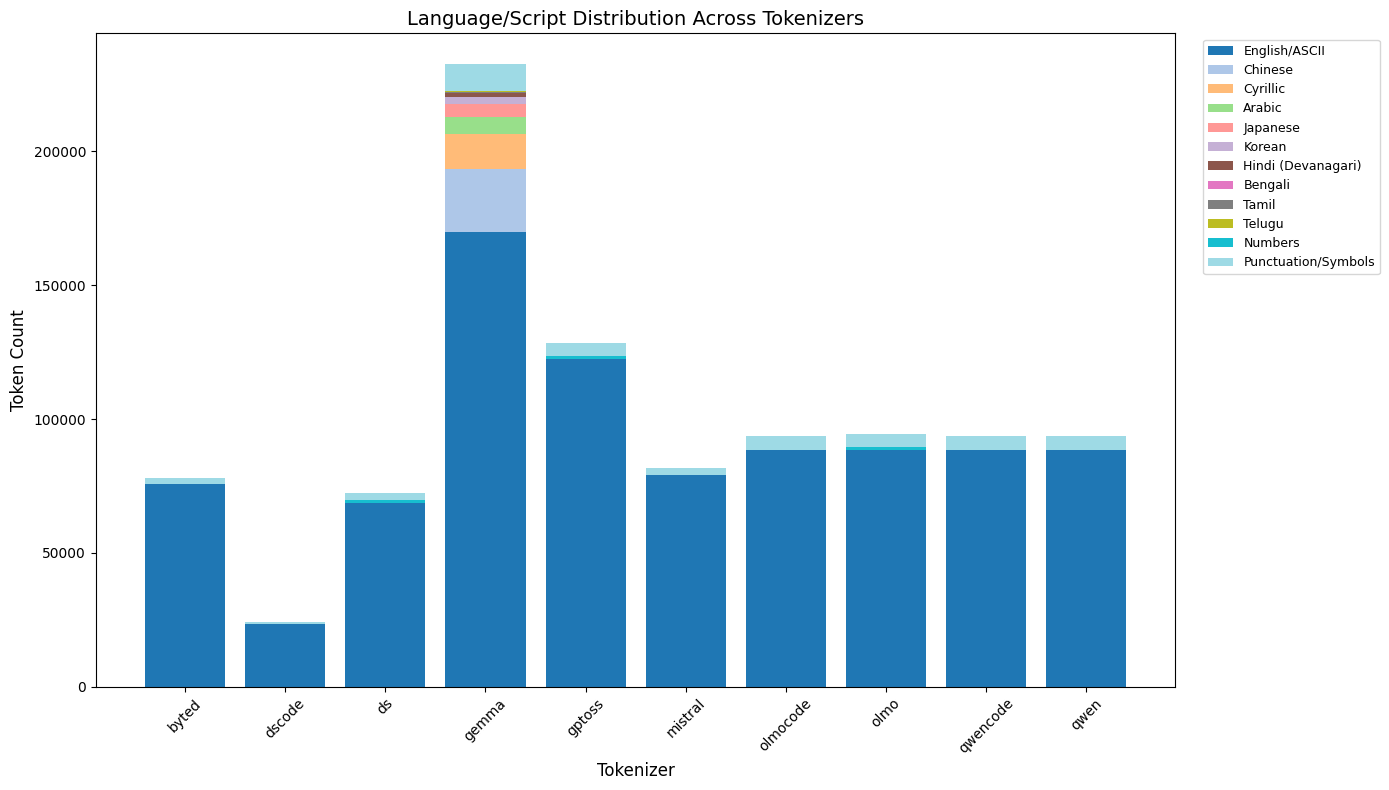


Language Distribution (% of vocabulary):
           English/ASCII  Chinese  Cyrillic  Arabic  Japanese  Korean  Hindi (Devanagari)  Bengali  Tamil  Telugu  Numbers  Punctuation/Symbols
Tokenizer                                                                                                                                      
byted              48.77      0.0      0.00    0.00      0.00    0.00                0.00     0.00   0.00    0.00     0.01                 1.40
dscode             72.79      0.0      0.00    0.00      0.00    0.00                0.00     0.00   0.00    0.00     0.03                 2.75
ds                 53.67      0.0      0.00    0.00      0.00    0.00                0.00     0.00   0.00    0.00     0.87                 1.87
gemma              66.31      9.3      5.12    2.39      1.98    0.91                0.59     0.11   0.13    0.09     0.00                 3.88
gptoss             61.25      0.0      0.00    0.00      0.00    0.00                0.00     

In [7]:
# Cell 7: Language distribution chart

# Create stacked bar chart for top languages
top_languages = ['English/ASCII', 'Chinese', 'Cyrillic', 'Arabic', 'Japanese', 'Korean',
                 'Hindi (Devanagari)', 'Bengali', 'Tamil', 'Telugu', 'Numbers', 'Punctuation/Symbols']

# Filter to top languages that exist in data
available_langs = [lang for lang in top_languages if lang in df_lang.columns]

fig, ax = plt.subplots(figsize=(14, 8))

# Create stacked bar chart
bottom = np.zeros(len(df_lang))
colors = plt.cm.tab20(np.linspace(0, 1, len(available_langs)))

for i, lang in enumerate(available_langs):
    if lang in df_lang.columns:
        values = df_lang[lang].values
        ax.bar(df_lang.index, values, bottom=bottom, label=lang, color=colors[i])
        bottom += values

ax.set_xlabel('Tokenizer', fontsize=12)
ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Language/Script Distribution Across Tokenizers', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Create percentage-based comparison
print("\nLanguage Distribution (% of vocabulary):")
df_lang_pct = df_lang.div(df_lang.sum(axis=1), axis=0) * 100
print(df_lang_pct[available_langs].round(2).to_string())

In [8]:
# Cell 8: Indic and English language coverage

print("="*60)
print("5. INDIC AND ENGLISH LANGUAGE COVERAGE")
print("="*60)

indic_scripts = ['Hindi (Devanagari)', 'Bengali', 'Tamil', 'Telugu', 'Kannada', 
                 'Malayalam', 'Gujarati', 'Odia', 'Punjabi (Gurmukhi)']

indic_english_stats = []

for name, tok_data in tokenizers.items():
    total_vocab = len(tok_data['vocab'])
    
    # Count Indic tokens
    indic_counts = {}
    total_indic = 0
    english_count = 0
    
    for token in tok_data['vocab'].keys():
        lang = detect_language(token)
        if lang in indic_scripts:
            indic_counts[lang] = indic_counts.get(lang, 0) + 1
            total_indic += 1
        elif lang == 'English/ASCII':
            english_count += 1
    
    stats = {
        'Tokenizer': name,
        'Total Vocab': total_vocab,
        'English Tokens': english_count,
        'English %': round(english_count / total_vocab * 100, 2) if total_vocab > 0 else 0,
        'Total Indic': total_indic,
        'Indic %': round(total_indic / total_vocab * 100, 2) if total_vocab > 0 else 0,
    }
    
    # Add individual Indic language counts
    for lang in indic_scripts:
        stats[lang] = indic_counts.get(lang, 0)
    
    indic_english_stats.append(stats)
    
    print(f"\n{name.upper()}:")
    print(f"  English tokens: {english_count:,} ({stats['English %']:.2f}%)")
    print(f"  Total Indic tokens: {total_indic:,} ({stats['Indic %']:.2f}%)")
    if total_indic > 0:
        print("  Indic breakdown:")
        for lang in indic_scripts:
            if indic_counts.get(lang, 0) > 0:
                print(f"    {lang}: {indic_counts[lang]:,}")

df_indic_english = pd.DataFrame(indic_english_stats)
df_indic_english = df_indic_english.sort_values('Total Indic', ascending=False)

# Save to CSV
df_indic_english.to_csv(OUTPUT_DIR / 'indic_english_coverage.csv', index=False)
print(f"\nSaved to {OUTPUT_DIR / 'indic_english_coverage.csv'}")

5. INDIC AND ENGLISH LANGUAGE COVERAGE

BYTED:
  English tokens: 75,655 (48.77%)
  Total Indic tokens: 0 (0.00%)

DSCODE:
  English tokens: 23,294 (72.79%)
  Total Indic tokens: 0 (0.00%)

DS:
  English tokens: 68,700 (53.67%)
  Total Indic tokens: 0 (0.00%)

GEMMA:
  English tokens: 169,742 (66.31%)
  Total Indic tokens: 3,088 (1.21%)
  Indic breakdown:
    Hindi (Devanagari): 1,516
    Bengali: 289
    Tamil: 325
    Telugu: 233
    Kannada: 154
    Malayalam: 198
    Gujarati: 160
    Odia: 69
    Punjabi (Gurmukhi): 144

GPTOSS:
  English tokens: 122,490 (61.25%)
  Total Indic tokens: 0 (0.00%)

MISTRAL:
  English tokens: 78,901 (60.20%)
  Total Indic tokens: 0 (0.00%)

OLMOCODE:
  English tokens: 88,492 (58.36%)
  Total Indic tokens: 0 (0.00%)

OLMO:
  English tokens: 88,281 (88.04%)
  Total Indic tokens: 0 (0.00%)

QWENCODE:
  English tokens: 88,492 (58.36%)
  Total Indic tokens: 0 (0.00%)

QWEN:
  English tokens: 88,492 (58.36%)
  Total Indic tokens: 0 (0.00%)

Saved to output\i

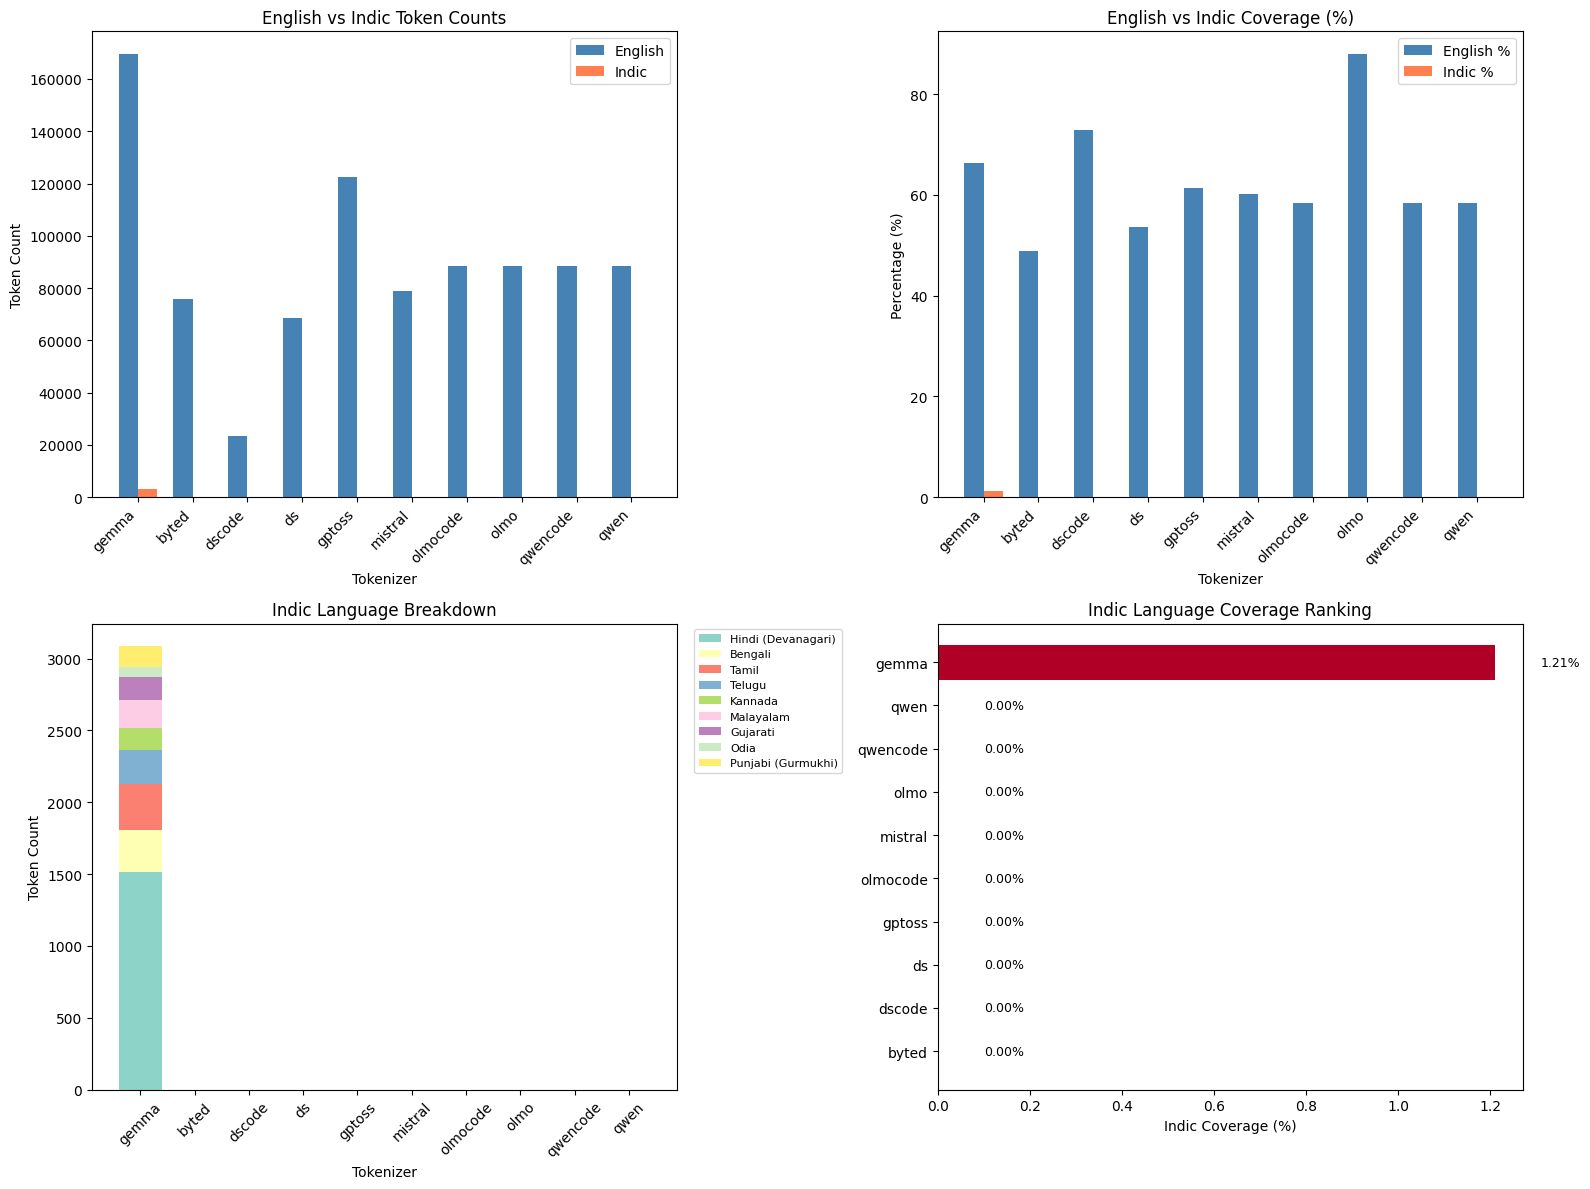

In [9]:
# Cell 9: Indic and English coverage charts

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: English vs Indic comparison (bar chart)
ax1 = axes[0, 0]
x = np.arange(len(df_indic_english))
width = 0.35
ax1.bar(x - width/2, df_indic_english['English Tokens'], width, label='English', color='steelblue')
ax1.bar(x + width/2, df_indic_english['Total Indic'], width, label='Indic', color='coral')
ax1.set_xlabel('Tokenizer')
ax1.set_ylabel('Token Count')
ax1.set_title('English vs Indic Token Counts')
ax1.set_xticks(x)
ax1.set_xticklabels(df_indic_english['Tokenizer'], rotation=45, ha='right')
ax1.legend()

# Chart 2: English vs Indic percentages
ax2 = axes[0, 1]
ax2.bar(x - width/2, df_indic_english['English %'], width, label='English %', color='steelblue')
ax2.bar(x + width/2, df_indic_english['Indic %'], width, label='Indic %', color='coral')
ax2.set_xlabel('Tokenizer')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('English vs Indic Coverage (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(df_indic_english['Tokenizer'], rotation=45, ha='right')
ax2.legend()

# Chart 3: Indic language breakdown (stacked)
ax3 = axes[1, 0]
indic_cols = [col for col in indic_scripts if col in df_indic_english.columns]
bottom = np.zeros(len(df_indic_english))
colors = plt.cm.Set3(np.linspace(0, 1, len(indic_cols)))

for i, col in enumerate(indic_cols):
    values = df_indic_english[col].values
    if values.sum() > 0:
        ax3.bar(df_indic_english['Tokenizer'], values, bottom=bottom, label=col, color=colors[i])
        bottom += values

ax3.set_xlabel('Tokenizer')
ax3.set_ylabel('Token Count')
ax3.set_title('Indic Language Breakdown')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Chart 4: Indic token percentage radar-like comparison (using horizontal bars)
ax4 = axes[1, 1]
df_sorted = df_indic_english.sort_values('Indic %', ascending=True)
colors_indic = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_sorted)))
ax4.barh(df_sorted['Tokenizer'], df_sorted['Indic %'], color=colors_indic)
ax4.set_xlabel('Indic Coverage (%)')
ax4.set_title('Indic Language Coverage Ranking')

for i, (idx, row) in enumerate(df_sorted.iterrows()):
    ax4.text(row['Indic %'] + 0.1, i, f"{row['Indic %']:.2f}%", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'indic_english_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Cell 10: Code handling token coverage

print("="*60)
print("6. CODE HANDLING TOKEN COVERAGE")
print("="*60)

# Extended code-related patterns for better detection
def analyze_code_tokens(vocab):
    """Detailed analysis of code-related tokens"""
    categories = {
        'keywords': [],
        'operators': [],
        'brackets': [],
        'indentation': [],
        'comments': [],
        'identifiers': [],
        'sql': [],
        'api': [],
        'other_code': []
    }
    
    keyword_pattern = r'^(def|class|function|const|let|var|import|from|return|if|else|elif|for|while|try|except|catch|finally|async|await|yield|lambda|public|private|protected|static|void|int|float|double|string|bool|null|None|true|false|True|False|undefined|this|self|super|new|delete|throw|throws|extends|implements|interface|abstract|virtual|override|final|package|namespace|using|include|require|export|module|type|enum|struct|union|sizeof|typeof|instanceof)$'
    operator_pattern = r'^(=>|->|::|&&|\|\||==|!=|<=|>=|\+=|-=|\*=|/=|%=|&=|\|=|\^=|<<=|>>=|===|!==|\+\+|--|<<|>>|>>>)$'
    bracket_pattern = r'^[{}\[\]()<>]$'
    indent_pattern = r'^(\s{2,}|\t+)$'
    comment_pattern = r'^(//|#|/\*|\*/|<!--|-->|"""|\'\'\'|```)'
    sql_pattern = r'^(SELECT|INSERT|UPDATE|DELETE|FROM|WHERE|JOIN|ORDER|GROUP|BY|HAVING|LIMIT|OFFSET|CREATE|DROP|ALTER|TABLE|INDEX|VIEW|TRIGGER|PROCEDURE|FUNCTION|PRIMARY|FOREIGN|KEY|REFERENCES|CONSTRAINT|UNIQUE|NOT|NULL|DEFAULT|AUTO_INCREMENT|CASCADE|INNER|LEFT|RIGHT|OUTER|CROSS|ON|AS|AND|OR|IN|BETWEEN|LIKE|IS|EXISTS|UNION|INTERSECT|EXCEPT|DISTINCT|ALL|ANY|SOME)$'
    api_pattern = r'^(GET|POST|PUT|DELETE|PATCH|HEAD|OPTIONS|HTTP|HTTPS|API|REST|GraphQL|JSON|XML|URL|URI|CORS|OAuth|JWT|Bearer|Authorization|Content-Type|Accept|Cache-Control)$'
    
    for token in vocab.keys():
        decoded = decode_bpe_token(token).strip()
        
        if re.match(keyword_pattern, decoded, re.IGNORECASE):
            categories['keywords'].append(token)
        elif re.match(operator_pattern, decoded):
            categories['operators'].append(token)
        elif re.match(bracket_pattern, decoded):
            categories['brackets'].append(token)
        elif re.match(indent_pattern, decoded):
            categories['indentation'].append(token)
        elif re.match(comment_pattern, decoded):
            categories['comments'].append(token)
        elif re.match(sql_pattern, decoded, re.IGNORECASE):
            categories['sql'].append(token)
        elif re.match(api_pattern, decoded, re.IGNORECASE):
            categories['api'].append(token)
        elif is_code_token(token):
            categories['other_code'].append(token)
    
    return categories

code_stats = []

for name, tok_data in tokenizers.items():
    categories = analyze_code_tokens(tok_data['vocab'])
    total_vocab = len(tok_data['vocab'])
    
    total_code = sum(len(v) for v in categories.values())
    
    stats = {
        'Tokenizer': name,
        'Total Vocab': total_vocab,
        'Total Code Tokens': total_code,
        'Code %': round(total_code / total_vocab * 100, 2) if total_vocab > 0 else 0,
        'Keywords': len(categories['keywords']),
        'Operators': len(categories['operators']),
        'Brackets': len(categories['brackets']),
        'Indentation': len(categories['indentation']),
        'Comments': len(categories['comments']),
        'SQL': len(categories['sql']),
        'API': len(categories['api']),
        'Other Code': len(categories['other_code'])
    }
    code_stats.append(stats)
    
    print(f"\n{name.upper()}:")
    print(f"  Total code-related tokens: {total_code:,} ({stats['Code %']:.2f}%)")
    print(f"  - Keywords: {len(categories['keywords'])}")
    print(f"  - Operators: {len(categories['operators'])}")
    print(f"  - Brackets: {len(categories['brackets'])}")
    print(f"  - SQL keywords: {len(categories['sql'])}")
    print(f"  - API/HTTP related: {len(categories['api'])}")

df_code = pd.DataFrame(code_stats).sort_values('Total Code Tokens', ascending=False)
df_code.to_csv(OUTPUT_DIR / 'code_token_coverage.csv', index=False)
print(f"\nSaved to {OUTPUT_DIR / 'code_token_coverage.csv'}")

6. CODE HANDLING TOKEN COVERAGE

BYTED:
  Total code-related tokens: 1,421 (0.92%)
  - Keywords: 331
  - Operators: 51
  - Brackets: 49
  - SQL keywords: 249
  - API/HTTP related: 98

DSCODE:
  Total code-related tokens: 792 (2.48%)
  - Keywords: 247
  - Operators: 37
  - Brackets: 54
  - SQL keywords: 199
  - API/HTTP related: 69

DS:
  Total code-related tokens: 1,195 (0.93%)
  - Keywords: 310
  - Operators: 57
  - Brackets: 54
  - SQL keywords: 239
  - API/HTTP related: 90

GEMMA:
  Total code-related tokens: 2,827 (1.10%)
  - Keywords: 181
  - Operators: 26
  - Brackets: 27
  - SQL keywords: 144
  - API/HTTP related: 60

GPTOSS:
  Total code-related tokens: 1,636 (0.82%)
  - Keywords: 401
  - Operators: 73
  - Brackets: 64
  - SQL keywords: 298
  - API/HTTP related: 125

MISTRAL:
  Total code-related tokens: 1,040 (0.79%)
  - Keywords: 318
  - Operators: 53
  - Brackets: 56
  - SQL keywords: 241
  - API/HTTP related: 98

OLMOCODE:
  Total code-related tokens: 3,672 (2.42%)
  - Keyw

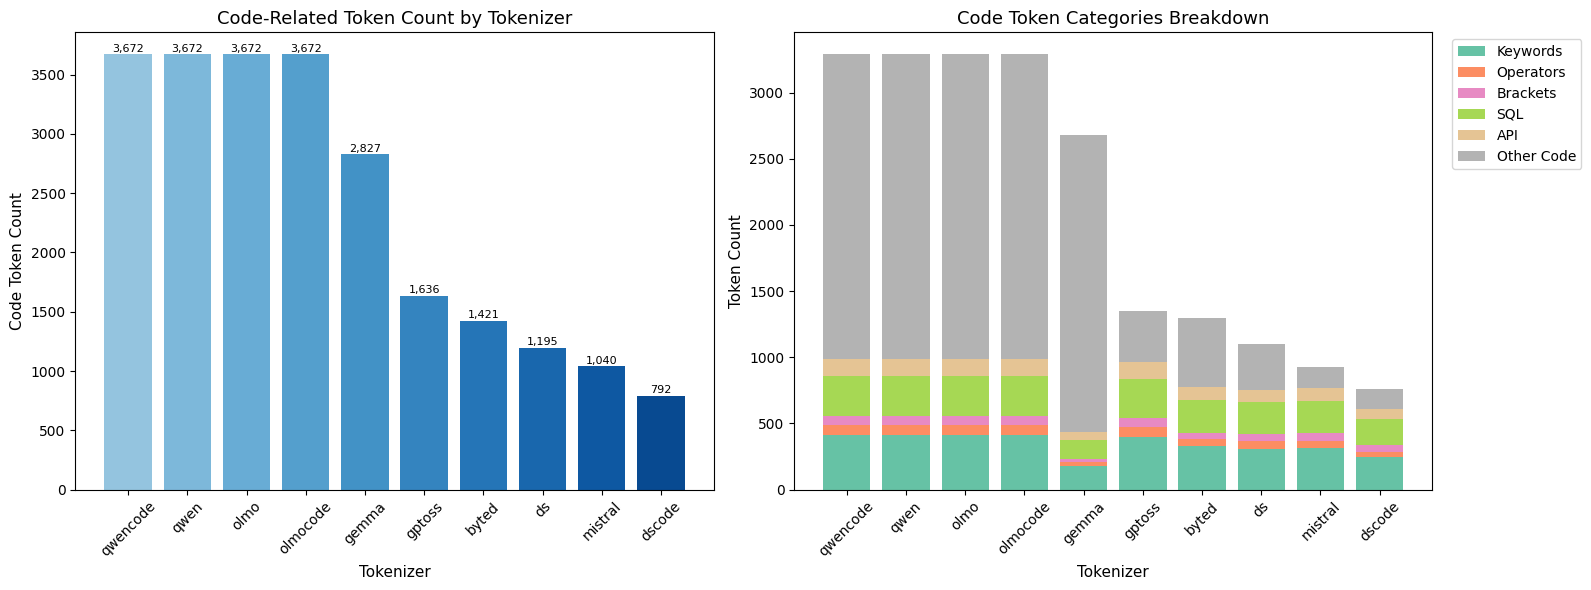

In [11]:
# Cell 11: Code token coverage chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Total code tokens
ax1 = axes[0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_code)))
bars = ax1.bar(df_code['Tokenizer'], df_code['Total Code Tokens'], color=colors)
ax1.set_xlabel('Tokenizer', fontsize=11)
ax1.set_ylabel('Code Token Count', fontsize=11)
ax1.set_title('Code-Related Token Count by Tokenizer', fontsize=13)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, df_code['Total Code Tokens']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# Chart 2: Code token breakdown (stacked)
ax2 = axes[1]
code_categories = ['Keywords', 'Operators', 'Brackets', 'SQL', 'API', 'Other Code']
bottom = np.zeros(len(df_code))
colors_cat = plt.cm.Set2(np.linspace(0, 1, len(code_categories)))

for i, cat in enumerate(code_categories):
    if cat in df_code.columns:
        values = df_code[cat].values
        ax2.bar(df_code['Tokenizer'], values, bottom=bottom, label=cat, color=colors_cat[i])
        bottom += values

ax2.set_xlabel('Tokenizer', fontsize=11)
ax2.set_ylabel('Token Count', fontsize=11)
ax2.set_title('Code Token Categories Breakdown', fontsize=13)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'code_token_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Cell 12: JSON handling capabilities analysis

print("="*60)
print("7. JSON HANDLING CAPABILITIES")
print("="*60)

def analyze_json_tokens(vocab, added_tokens):
    """Analyze JSON-related tokens"""
    categories = {
        'structural': [],      # { } [ ] : ,
        'literals': [],        # true, false, null
        'quotes': [],          # " '
        'json_keywords': [],   # json, JSON, parse, stringify
        'escape_sequences': [], # \n \t \\ \"
        'special_json': []     # Special JSON-related added tokens
    }
    
    structural_pattern = r'^[{}\[\]:,]$'
    literal_pattern = r'^(true|false|null)$'
    quote_pattern = r'^["\']$'
    json_keyword_pattern = r'^(json|JSON|Json|parse|stringify|dumps|loads|serialize|deserialize|marshal|unmarshal|encode|decode)$'
    escape_pattern = r'^\\[nrt\\"/bfu]$'
    
    for token in vocab.keys():
        decoded = decode_bpe_token(token).strip()
        
        if re.match(structural_pattern, decoded):
            categories['structural'].append(token)
        elif re.match(literal_pattern, decoded, re.IGNORECASE):
            categories['literals'].append(token)
        elif re.match(quote_pattern, decoded):
            categories['quotes'].append(token)
        elif re.match(json_keyword_pattern, decoded, re.IGNORECASE):
            categories['json_keywords'].append(token)
        elif re.match(escape_pattern, decoded):
            categories['escape_sequences'].append(token)
    
    # Check added tokens for JSON-related special tokens
    for token_info in added_tokens:
        content = token_info.get('content', '')
        if any(kw in content.lower() for kw in ['json', 'object', 'array', 'key', 'value']):
            categories['special_json'].append(content)
    
    return categories

json_stats = []

for name, tok_data in tokenizers.items():
    categories = analyze_json_tokens(tok_data['vocab'], tok_data['added_tokens'])
    total_vocab = len(tok_data['vocab'])
    
    total_json = sum(len(v) for v in categories.values())
    
    stats = {
        'Tokenizer': name,
        'Total JSON Tokens': total_json,
        'Structural ({},[],:,)': len(categories['structural']),
        'Literals (true/false/null)': len(categories['literals']),
        'Quotes': len(categories['quotes']),
        'JSON Keywords': len(categories['json_keywords']),
        'Escape Sequences': len(categories['escape_sequences']),
        'Special JSON Tokens': len(categories['special_json'])
    }
    json_stats.append(stats)
    
    print(f"\n{name.upper()}:")
    print(f"  Total JSON-related tokens: {total_json}")
    print(f"  - Structural chars: {len(categories['structural'])}")
    print(f"  - Literals: {len(categories['literals'])}")
    print(f"  - JSON keywords: {len(categories['json_keywords'])}")
    print(f"  - Special JSON tokens: {len(categories['special_json'])}")
    if categories['special_json']:
        print(f"    Samples: {categories['special_json'][:5]}")

df_json = pd.DataFrame(json_stats).sort_values('Total JSON Tokens', ascending=False)
df_json.to_csv(OUTPUT_DIR / 'json_token_coverage.csv', index=False)
print(f"\nSaved to {OUTPUT_DIR / 'json_token_coverage.csv'}")

7. JSON HANDLING CAPABILITIES

BYTED:
  Total JSON-related tokens: 103
  - Structural chars: 38
  - Literals: 18
  - JSON keywords: 25
  - Special JSON tokens: 0

DSCODE:
  Total JSON-related tokens: 58
  - Structural chars: 15
  - Literals: 18
  - JSON keywords: 13
  - Special JSON tokens: 0

DS:
  Total JSON-related tokens: 103
  - Structural chars: 43
  - Literals: 17
  - JSON keywords: 18
  - Special JSON tokens: 0

GEMMA:
  Total JSON-related tokens: 60
  - Structural chars: 20
  - Literals: 9
  - JSON keywords: 23
  - Special JSON tokens: 0

GPTOSS:
  Total JSON-related tokens: 140
  - Structural chars: 50
  - Literals: 23
  - JSON keywords: 40
  - Special JSON tokens: 0

MISTRAL:
  Total JSON-related tokens: 108
  - Structural chars: 42
  - Literals: 18
  - JSON keywords: 24
  - Special JSON tokens: 0

OLMOCODE:
  Total JSON-related tokens: 149
  - Structural chars: 55
  - Literals: 23
  - JSON keywords: 40
  - Special JSON tokens: 2
    Samples: ['<|object_ref_start|>', '<|obje

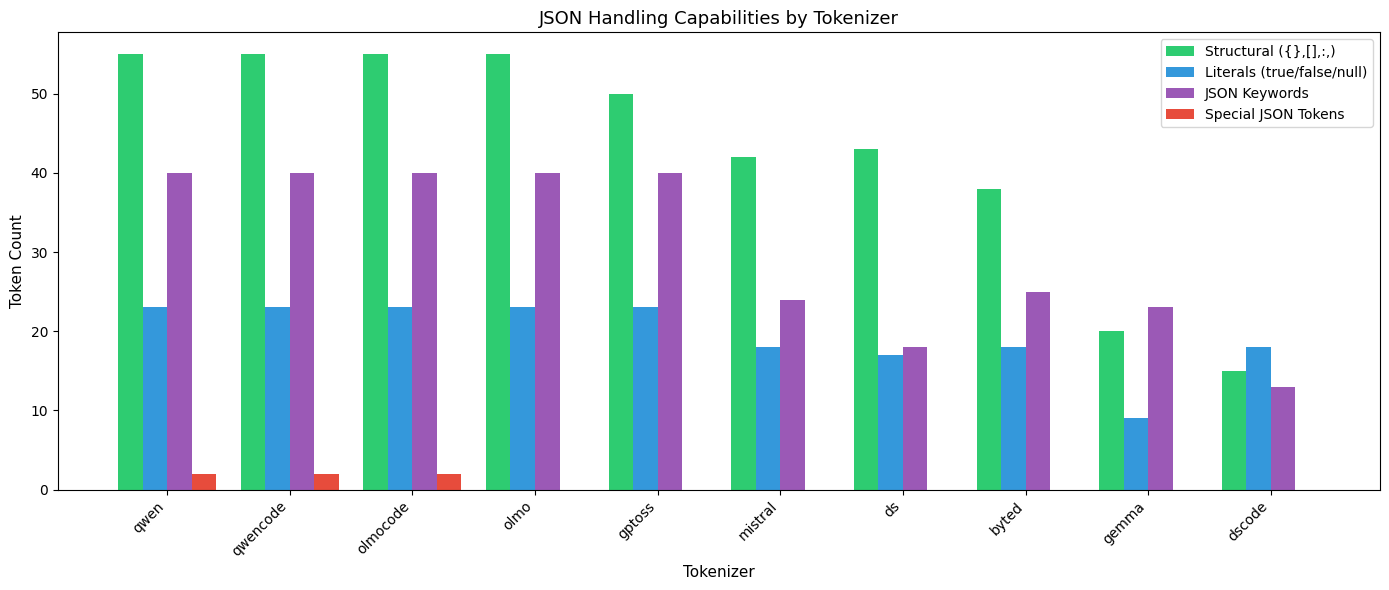


JSON Capabilities Summary:
Tokenizer  Total JSON Tokens  Structural ({},[],:,)  Literals (true/false/null)  Quotes  JSON Keywords  Escape Sequences  Special JSON Tokens
     qwen                149                     55                          23      16             40                13                    2
 qwencode                149                     55                          23      16             40                13                    2
 olmocode                149                     55                          23      16             40                13                    2
     olmo                147                     55                          23      16             40                13                    0
   gptoss                140                     50                          23      15             40                12                    0
  mistral                108                     42                          18      13             24                11

In [13]:
# Cell 13: JSON capabilities chart

fig, ax = plt.subplots(figsize=(14, 6))

json_categories = ['Structural ({},[],:,)', 'Literals (true/false/null)', 'JSON Keywords', 'Special JSON Tokens']
x = np.arange(len(df_json))
width = 0.2
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for i, cat in enumerate(json_categories):
    if cat in df_json.columns:
        offset = (i - len(json_categories)/2 + 0.5) * width
        ax.bar(x + offset, df_json[cat], width, label=cat, color=colors[i])

ax.set_xlabel('Tokenizer', fontsize=11)
ax.set_ylabel('Token Count', fontsize=11)
ax.set_title('JSON Handling Capabilities by Tokenizer', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_json['Tokenizer'], rotation=45, ha='right')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'json_capabilities.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nJSON Capabilities Summary:")
print(df_json.to_string(index=False))

In [14]:
# Cell 14: Function call handling capabilities

print("="*60)
print("8. FUNCTION CALL HANDLING CAPABILITIES")
print("="*60)

def analyze_function_call_tokens(vocab, added_tokens):
    """Analyze function call related tokens"""
    categories = {
        'function_keywords': [],
        'call_keywords': [],
        'parameter_keywords': [],
        'async_keywords': [],
        'parentheses': [],
        'special_function_tokens': [],
        'tool_tokens': []
    }
    
    function_pattern = r'^(function|func|fn|def|method|procedure|subroutine|lambda|arrow|closure)$'
    call_pattern = r'^(call|invoke|execute|run|apply|bind|trigger|dispatch|emit)$'
    param_pattern = r'^(args|arguments|params|parameters|kwargs|options|config|settings|props|properties)$'
    async_pattern = r'^(async|await|promise|then|catch|finally|resolve|reject|callback|handler)$'
    paren_pattern = r'^[\(\)]$'
    
    for token in vocab.keys():
        decoded = decode_bpe_token(token).strip()
        
        if re.match(function_pattern, decoded, re.IGNORECASE):
            categories['function_keywords'].append(token)
        elif re.match(call_pattern, decoded, re.IGNORECASE):
            categories['call_keywords'].append(token)
        elif re.match(param_pattern, decoded, re.IGNORECASE):
            categories['parameter_keywords'].append(token)
        elif re.match(async_pattern, decoded, re.IGNORECASE):
            categories['async_keywords'].append(token)
        elif re.match(paren_pattern, decoded):
            categories['parentheses'].append(token)
    
    # Check added tokens for function call related special tokens
    for token_info in added_tokens:
        content = token_info.get('content', '')
        content_lower = content.lower()
        
        # Check for tool/function call related special tokens
        if any(kw in content_lower for kw in ['tool', 'function', 'call', 'invoke', 'action', 'plugin']):
            categories['tool_tokens'].append(content)
        elif any(kw in content_lower for kw in ['start', 'end', 'begin', 'return', 'result']):
            categories['special_function_tokens'].append(content)
    
    return categories

func_stats = []

for name, tok_data in tokenizers.items():
    categories = analyze_function_call_tokens(tok_data['vocab'], tok_data['added_tokens'])
    
    total_func = sum(len(v) for v in categories.values())
    
    stats = {
        'Tokenizer': name,
        'Total Function Tokens': total_func,
        'Function Keywords': len(categories['function_keywords']),
        'Call Keywords': len(categories['call_keywords']),
        'Parameter Keywords': len(categories['parameter_keywords']),
        'Async Keywords': len(categories['async_keywords']),
        'Parentheses': len(categories['parentheses']),
        'Tool/Action Tokens': len(categories['tool_tokens']),
        'Special Tokens': len(categories['special_function_tokens'])
    }
    func_stats.append(stats)
    
    print(f"\n{name.upper()}:")
    print(f"  Total function-related tokens: {total_func}")
    print(f"  - Function keywords: {len(categories['function_keywords'])}")
    print(f"  - Call keywords: {len(categories['call_keywords'])}")
    print(f"  - Parameter keywords: {len(categories['parameter_keywords'])}")
    print(f"  - Async keywords: {len(categories['async_keywords'])}")
    print(f"  - Tool/Action special tokens: {len(categories['tool_tokens'])}")
    if categories['tool_tokens']:
        print(f"    Samples: {categories['tool_tokens'][:10]}")

df_func = pd.DataFrame(func_stats).sort_values('Total Function Tokens', ascending=False)
df_func.to_csv(OUTPUT_DIR / 'function_call_coverage.csv', index=False)
print(f"\nSaved to {OUTPUT_DIR / 'function_call_coverage.csv'}")

8. FUNCTION CALL HANDLING CAPABILITIES

BYTED:
  Total function-related tokens: 171
  - Function keywords: 44
  - Call keywords: 39
  - Parameter keywords: 40
  - Async keywords: 35
  - Tool/Action special tokens: 2
    Samples: ['<seed:tool_call>', '</seed:tool_call>']

DSCODE:
  Total function-related tokens: 125
  - Function keywords: 29
  - Call keywords: 28
  - Parameter keywords: 33
  - Async keywords: 26
  - Tool/Action special tokens: 0

DS:
  Total function-related tokens: 175
  - Function keywords: 44
  - Call keywords: 34
  - Parameter keywords: 37
  - Async keywords: 31
  - Tool/Action special tokens: 9
    Samples: ['<｜tool▁calls▁begin｜>', '<｜tool▁calls▁end｜>', '<｜tool▁call▁begin｜>', '<｜tool▁call▁end｜>', '<｜tool▁outputs▁begin｜>', '<｜tool▁outputs▁end｜>', '<｜tool▁output▁begin｜>', '<｜tool▁output▁end｜>', '<｜tool▁sep｜>']

GEMMA:
  Total function-related tokens: 118
  - Function keywords: 26
  - Call keywords: 25
  - Parameter keywords: 27
  - Async keywords: 29
  - Tool/Action 

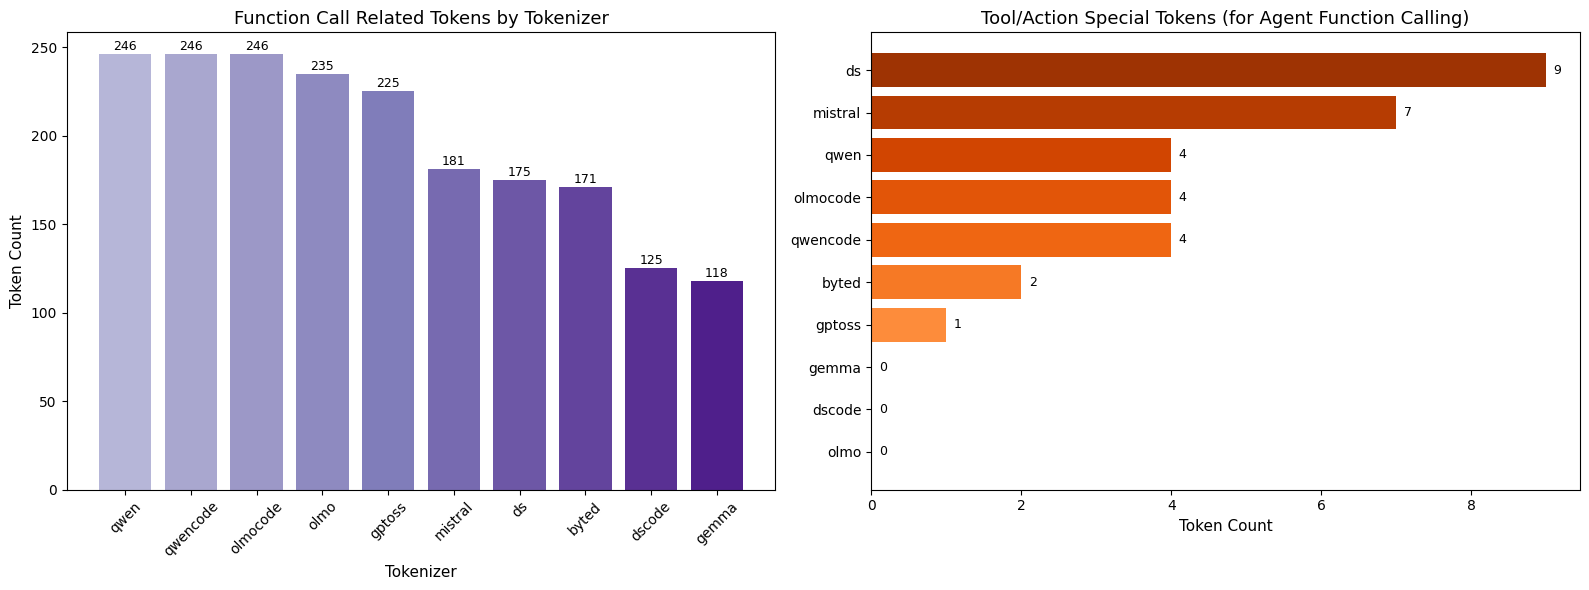


Function Call Capabilities Summary:
Tokenizer  Total Function Tokens  Function Keywords  Call Keywords  Parameter Keywords  Async Keywords  Parentheses  Tool/Action Tokens  Special Tokens
     qwen                    246                 54             49                  56              53           19                   4              11
 qwencode                    246                 54             49                  56              53           19                   4              11
 olmocode                    246                 54             49                  56              53           19                   4              11
     olmo                    235                 54             49                  56              53           19                   0               4
   gptoss                    225                 52             46                  54              50           16                   1               6
  mistral                    181                 43

In [15]:
# Cell 15: Function call capabilities chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Total function tokens
ax1 = axes[0]
colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(df_func)))
bars = ax1.bar(df_func['Tokenizer'], df_func['Total Function Tokens'], color=colors)
ax1.set_xlabel('Tokenizer', fontsize=11)
ax1.set_ylabel('Token Count', fontsize=11)
ax1.set_title('Function Call Related Tokens by Tokenizer', fontsize=13)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, df_func['Total Function Tokens']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val}', ha='center', va='bottom', fontsize=9)

# Chart 2: Tool/Action special tokens (important for agent/function calling)
ax2 = axes[1]
df_func_sorted = df_func.sort_values('Tool/Action Tokens', ascending=True)
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(df_func_sorted)))
ax2.barh(df_func_sorted['Tokenizer'], df_func_sorted['Tool/Action Tokens'], color=colors)
ax2.set_xlabel('Token Count', fontsize=11)
ax2.set_title('Tool/Action Special Tokens (for Agent Function Calling)', fontsize=13)

for i, (idx, row) in enumerate(df_func_sorted.iterrows()):
    ax2.text(row['Tool/Action Tokens'] + 0.1, i, f"{row['Tool/Action Tokens']}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'function_call_capabilities.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFunction Call Capabilities Summary:")
print(df_func.to_string(index=False))

In [16]:
# Cell 16: Comprehensive summary comparison

print("="*80)
print("COMPREHENSIVE TOKENIZER COMPARISON SUMMARY")
print("="*80)

# Build the comprehensive summary DataFrame
summary_data = []

for name, tok_data in tokenizers.items():
    total_vocab = len(tok_data['vocab']) + len(tok_data['added_tokens'])
    base_vocab = len(tok_data['vocab'])
    
    # Get tokens > 32 chars
    tokens_over_32 = sum(1 for t in tok_data['vocab'].keys() if get_token_length(t) > 32)
    pct_over_32 = round(tokens_over_32 / base_vocab * 100, 2) if base_vocab > 0 else 0
    
    # Get Indic stats from df_indic_english
    indic_row = df_indic_english[df_indic_english['Tokenizer'] == name].iloc[0] if len(df_indic_english[df_indic_english['Tokenizer'] == name]) > 0 else None
    
    # Get code stats
    code_row = df_code[df_code['Tokenizer'] == name].iloc[0] if len(df_code[df_code['Tokenizer'] == name]) > 0 else None
    
    # Get JSON stats
    json_row = df_json[df_json['Tokenizer'] == name].iloc[0] if len(df_json[df_json['Tokenizer'] == name]) > 0 else None
    
    # Get function call stats
    func_row = df_func[df_func['Tokenizer'] == name].iloc[0] if len(df_func[df_func['Tokenizer'] == name]) > 0 else None
    
    summary = {
        'Tokenizer': name,
        'Type': tok_data['type'],
        'Vocab Size': total_vocab,
        'Tokens > 32 chars': tokens_over_32,
        '% > 32 chars': pct_over_32,
        'English Tokens': int(indic_row['English Tokens']) if indic_row is not None else 0,
        'English %': float(indic_row['English %']) if indic_row is not None else 0,
        'Total Indic': int(indic_row['Total Indic']) if indic_row is not None else 0,
        'Indic %': float(indic_row['Indic %']) if indic_row is not None else 0,
        'Hindi': int(indic_row['Hindi (Devanagari)']) if indic_row is not None and 'Hindi (Devanagari)' in indic_row else 0,
        'Bengali': int(indic_row['Bengali']) if indic_row is not None and 'Bengali' in indic_row else 0,
        'Tamil': int(indic_row['Tamil']) if indic_row is not None and 'Tamil' in indic_row else 0,
        'Telugu': int(indic_row['Telugu']) if indic_row is not None and 'Telugu' in indic_row else 0,
        'Code Tokens': int(code_row['Total Code Tokens']) if code_row is not None else 0,
        'Code %': float(code_row['Code %']) if code_row is not None else 0,
        'JSON Tokens': int(json_row['Total JSON Tokens']) if json_row is not None else 0,
        'Function Tokens': int(func_row['Total Function Tokens']) if func_row is not None else 0,
        'Tool/Action Tokens': int(func_row['Tool/Action Tokens']) if func_row is not None else 0
    }
    summary_data.append(summary)

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Vocab Size', ascending=False)

# Display the summary
print("\n" + "="*80)
print("FULL COMPARISON TABLE")
print("="*80)
print(df_summary.to_string(index=False))

# Save comprehensive summary
df_summary.to_csv(OUTPUT_DIR / 'tokenizer_comprehensive_summary.csv', index=False)
print(f"\nComprehensive summary saved to {OUTPUT_DIR / 'tokenizer_comprehensive_summary.csv'}")

COMPREHENSIVE TOKENIZER COMPARISON SUMMARY

FULL COMPARISON TABLE
Tokenizer Type  Vocab Size  Tokens > 32 chars  % > 32 chars  English Tokens  English %  Total Indic  Indic %  Hindi  Bengali  Tamil  Telugu  Code Tokens  Code %  JSON Tokens  Function Tokens  Tool/Action Tokens
    gemma  BPE      256247                  0          0.00          169742      66.31         3088     1.21   1516      289    325     233         2827    1.10           60              118                   0
   gptoss  BPE      200019                266          0.13          122490      61.25            0     0.00      0        0      0       0         1636    0.82          140              225                   1
    byted  BPE      155249                 75          0.05           75655      48.77            0     0.00      0        0      0       0         1421    0.92          103              171                   2
     qwen  BPE      151669                240          0.16           88492      58.36    

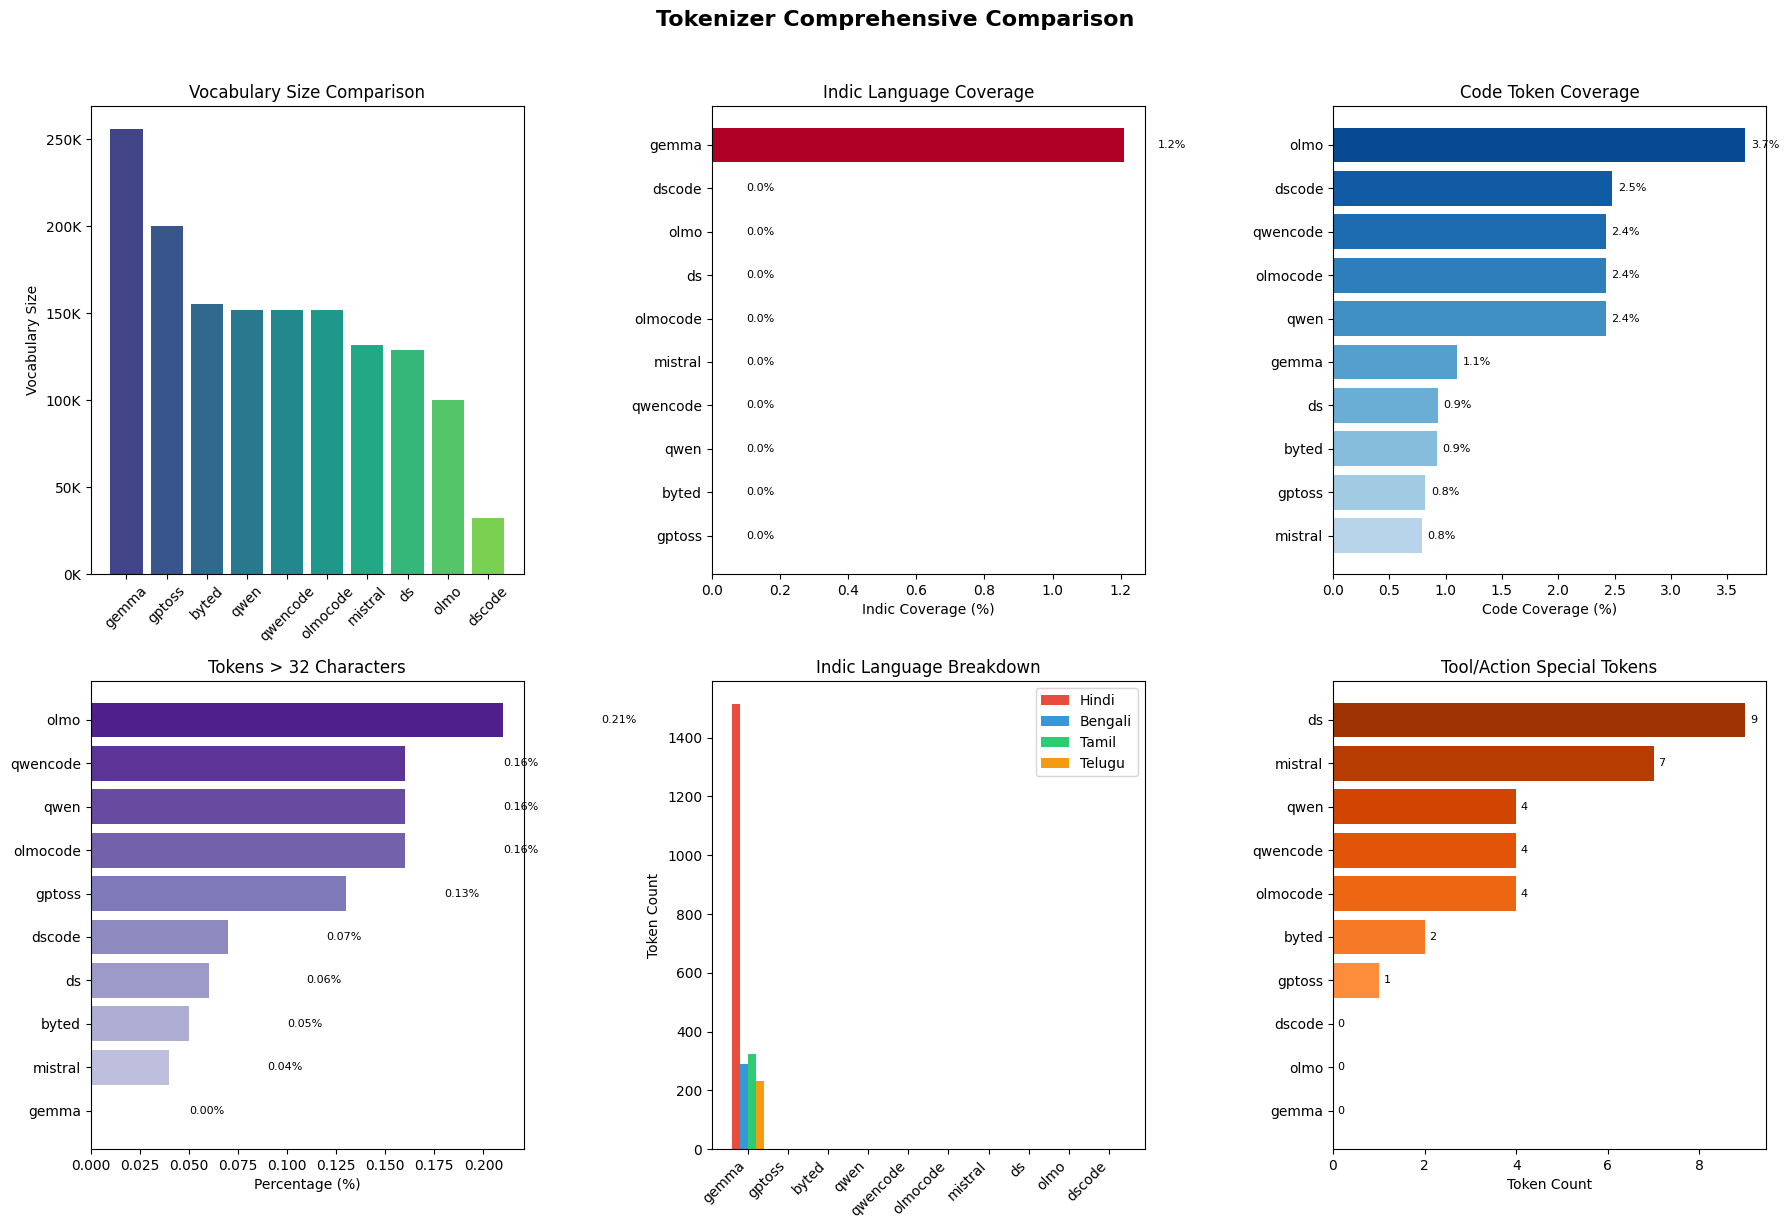


All charts saved to charts/


In [17]:
# Cell 17: Final comprehensive comparison charts

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Chart 1: Vocabulary Size
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_summary)))
bars = ax1.bar(df_summary['Tokenizer'], df_summary['Vocab Size'], color=colors)
ax1.set_ylabel('Vocabulary Size')
ax1.set_title('Vocabulary Size Comparison')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Chart 2: Indic Coverage
ax2 = axes[0, 1]
df_sorted_indic = df_summary.sort_values('Indic %', ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_sorted_indic)))
ax2.barh(df_sorted_indic['Tokenizer'], df_sorted_indic['Indic %'], color=colors)
ax2.set_xlabel('Indic Coverage (%)')
ax2.set_title('Indic Language Coverage')
for i, (idx, row) in enumerate(df_sorted_indic.iterrows()):
    ax2.text(row['Indic %'] + 0.1, i, f"{row['Indic %']:.1f}%", va='center', fontsize=8)

# Chart 3: Code Token Coverage
ax3 = axes[0, 2]
df_sorted_code = df_summary.sort_values('Code %', ascending=True)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(df_sorted_code)))
ax3.barh(df_sorted_code['Tokenizer'], df_sorted_code['Code %'], color=colors)
ax3.set_xlabel('Code Coverage (%)')
ax3.set_title('Code Token Coverage')
for i, (idx, row) in enumerate(df_sorted_code.iterrows()):
    ax3.text(row['Code %'] + 0.05, i, f"{row['Code %']:.1f}%", va='center', fontsize=8)

# Chart 4: Tokens > 32 characters
ax4 = axes[1, 0]
df_sorted_long = df_summary.sort_values('% > 32 chars', ascending=True)
colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(df_sorted_long)))
ax4.barh(df_sorted_long['Tokenizer'], df_sorted_long['% > 32 chars'], color=colors)
ax4.set_xlabel('Percentage (%)')
ax4.set_title('Tokens > 32 Characters')
for i, (idx, row) in enumerate(df_sorted_long.iterrows()):
    ax4.text(row['% > 32 chars'] + 0.05, i, f"{row['% > 32 chars']:.2f}%", va='center', fontsize=8)

# Chart 5: Indic Language Breakdown (top 4)
ax5 = axes[1, 1]
indic_langs = ['Hindi', 'Bengali', 'Tamil', 'Telugu']
x = np.arange(len(df_summary))
width = 0.2
colors_indic = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, lang in enumerate(indic_langs):
    if lang in df_summary.columns:
        offset = (i - len(indic_langs)/2 + 0.5) * width
        ax5.bar(x + offset, df_summary[lang], width, label=lang, color=colors_indic[i])

ax5.set_ylabel('Token Count')
ax5.set_title('Indic Language Breakdown')
ax5.set_xticks(x)
ax5.set_xticklabels(df_summary['Tokenizer'], rotation=45, ha='right')
ax5.legend()

# Chart 6: Tool/Function Call Capabilities
ax6 = axes[1, 2]
df_sorted_tool = df_summary.sort_values('Tool/Action Tokens', ascending=True)
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(df_sorted_tool)))
ax6.barh(df_sorted_tool['Tokenizer'], df_sorted_tool['Tool/Action Tokens'], color=colors)
ax6.set_xlabel('Token Count')
ax6.set_title('Tool/Action Special Tokens')
for i, (idx, row) in enumerate(df_sorted_tool.iterrows()):
    ax6.text(row['Tool/Action Tokens'] + 0.1, i, f"{int(row['Tool/Action Tokens'])}", va='center', fontsize=8)

plt.suptitle('Tokenizer Comprehensive Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll charts saved to {CHARTS_DIR}/")

In [18]:
# Cell 18: Final summary table with formatted output

print("="*100)
print("FINAL TOKENIZER COMPARISON SUMMARY")
print("="*100)

# Create a nicely formatted summary
summary_display = df_summary[['Tokenizer', 'Type', 'Vocab Size', 'Tokens > 32 chars', '% > 32 chars',
                               'Total Indic', 'Indic %', 'Code Tokens', 'Code %', 
                               'JSON Tokens', 'Function Tokens', 'Tool/Action Tokens']].copy()

# Format large numbers
summary_display['Vocab Size'] = summary_display['Vocab Size'].apply(lambda x: f'{x:,}')
summary_display['Tokens > 32 chars'] = summary_display['Tokens > 32 chars'].apply(lambda x: f'{x:,}')
summary_display['Total Indic'] = summary_display['Total Indic'].apply(lambda x: f'{x:,}')
summary_display['Code Tokens'] = summary_display['Code Tokens'].apply(lambda x: f'{x:,}')

print("\n📊 OVERVIEW:")
print(summary_display.to_string(index=False))

print("\n\n📈 KEY INSIGHTS:")
print("-" * 60)

# Find best in each category
best_vocab = df_summary.loc[df_summary['Vocab Size'].idxmax()]
best_indic = df_summary.loc[df_summary['Indic %'].idxmax()]
best_code = df_summary.loc[df_summary['Code %'].idxmax()]
best_tools = df_summary.loc[df_summary['Tool/Action Tokens'].idxmax()]
most_long_tokens = df_summary.loc[df_summary['% > 32 chars'].idxmax()]

print(f"🏆 Largest Vocabulary: {best_vocab['Tokenizer']} ({best_vocab['Vocab Size']:,} tokens)")
print(f"🇮🇳 Best Indic Coverage: {best_indic['Tokenizer']} ({best_indic['Indic %']:.2f}% - {int(best_indic['Total Indic']):,} tokens)")
print(f"💻 Best Code Coverage: {best_code['Tokenizer']} ({best_code['Code %']:.2f}%)")
print(f"🔧 Most Tool/Action Tokens: {best_tools['Tokenizer']} ({int(best_tools['Tool/Action Tokens'])} special tokens)")
print(f"📏 Most Long Tokens (>32): {most_long_tokens['Tokenizer']} ({most_long_tokens['% > 32 chars']:.2f}%)")

print("\n\n📋 INDIC LANGUAGE BREAKDOWN:")
print("-" * 60)
indic_breakdown = df_summary[['Tokenizer', 'Total Indic', 'Hindi', 'Bengali', 'Tamil', 'Telugu']].sort_values('Total Indic', ascending=False)
print(indic_breakdown.to_string(index=False))

print("\n\n📁 OUTPUT FILES GENERATED:")
print("-" * 60)
print(f"  📄 {OUTPUT_DIR / 'language_distribution.csv'}")
print(f"  📄 {OUTPUT_DIR / 'indic_english_coverage.csv'}")
print(f"  📄 {OUTPUT_DIR / 'code_token_coverage.csv'}")
print(f"  📄 {OUTPUT_DIR / 'json_token_coverage.csv'}")
print(f"  📄 {OUTPUT_DIR / 'function_call_coverage.csv'}")
print(f"  📄 {OUTPUT_DIR / 'tokenizer_comprehensive_summary.csv'}")

print("\n\n📊 CHARTS GENERATED:")
print("-" * 60)
for chart in CHARTS_DIR.glob("*.png"):
    print(f"  🖼️  {chart}")

print("\n" + "="*100)
print("Analysis Complete!")
print("="*100)

FINAL TOKENIZER COMPARISON SUMMARY

📊 OVERVIEW:
Tokenizer Type Vocab Size Tokens > 32 chars  % > 32 chars Total Indic  Indic % Code Tokens  Code %  JSON Tokens  Function Tokens  Tool/Action Tokens
    gemma  BPE    256,247                 0          0.00       3,088     1.21       2,827    1.10           60              118                   0
   gptoss  BPE    200,019               266          0.13           0     0.00       1,636    0.82          140              225                   1
    byted  BPE    155,249                75          0.05           0     0.00       1,421    0.92          103              171                   2
     qwen  BPE    151,669               240          0.16           0     0.00       3,672    2.42          149              246                   4
 qwencode  BPE    151,669               240          0.16           0     0.00       3,672    2.42          149              246                   4
 olmocode  BPE    151,669               240          0.16 